# Product Intelligence and Customer Review Analytics

### KPI-Based Product Segmentation and Explainable Sentiment Classification Using Amazon Beauty Reviews

**Author:** Daniyal Hemmati
**Field:** Management Information Systems
**Methods:** Statistical Analysis, K-Means Clustering, Principal Component Analysis, Natural Language Processing, TF-IDF, and Logistic Regression


## Executive Summary

Online marketplaces generate large volumes of customer feedback that cannot be analyzed manually at scale. This project develops a Product Intelligence framework using Amazon Beauty Reviews data to evaluate product performance, identify risk patterns, segment products into meaningful business groups, and automatically classify customer sentiment.

The analysis combines statistical analytics, machine learning, and natural language processing techniques. More than 700,000 customer reviews were transformed into product-level KPIs, including average rating, review volume, negative review rate, verified purchase rate, helpful votes, and review length.

The project further applies K-Means clustering to identify product segments, Principal Component Analysis (PCA) for visualization, and Logistic Regression with TF-IDF vectorization for sentiment classification.

The objective is to demonstrate how data analytics and AI-driven methods can support product management and decision-making in e-commerce environments.

## Research Questions

This project seeks to answer the following questions:

1. What insights can be extracted from Amazon customer reviews?

2. Which KPIs are most useful for evaluating product performance?

3. Can products be grouped into meaningful business segments?

4. Which products present the highest operational or reputational risk?

5. How strongly are different product KPIs related?

6. Can customer sentiment be automatically classified from review text?

7. Which words and phrases contribute most strongly to positive and negative sentiment predictions?

8. How can these findings support product management decisions?

## Analytical Workflow

The project follows the CRISP-DM analytics framework.

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Analysis
5. KPI Development
6. Product Segmentation
7. Sentiment Classification
8. Evaluation and Interpretation
9. Managerial Recommendations

## 1. Dataset Loading and Initial Validation

This section loads the Amazon Beauty Reviews dataset and performs basic validation. Before any analysis or machine learning, it is important to confirm that the file exists, the expected columns are available, and the dataset has been loaded correctly.

Each row in the dataset represents one customer review.

In [48]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
MIN_PRODUCT_REVIEWS = 20
ML_SAMPLE_SIZE = 100_000

DATA_PATH = Path("All_Beauty.jsonl.gz")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

warnings.filterwarnings("ignore", category=FutureWarning)

print("Environment initialized.")

Environment initialized.


In [49]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

reviews = pd.read_json(
    DATA_PATH,
    lines=True
)

print("Dataset loaded successfully.")
print("Shape:", reviews.shape)

display(reviews.head(3))

Dataset loaded successfully.
Shape: (701528, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True


In [35]:
expected_columns = {
    "rating",
    "title",
    "text",
    "images",
    "asin",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchase"
}

missing_columns = expected_columns.difference(reviews.columns)

if missing_columns:
    raise ValueError(
        f"Missing expected columns: {sorted(missing_columns)}"
    )

print("All expected columns are available.")
print("Review records:", f"{len(reviews):,}")
print("Unique products:", f"{reviews['parent_asin'].nunique():,}")
print("Unique reviewers:", f"{reviews['user_id'].nunique():,}")

All expected columns are available.
Review records: 701,528
Unique products: 112,565
Unique reviewers: 631,986


In [36]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             701528 non-null  int64         
 1   title              701528 non-null  object        
 2   text               701528 non-null  object        
 3   images             701528 non-null  object        
 4   asin               701528 non-null  object        
 5   parent_asin        701528 non-null  object        
 6   user_id            701528 non-null  object        
 7   timestamp          701528 non-null  datetime64[ns]
 8   helpful_vote       701528 non-null  int64         
 9   verified_purchase  701528 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 48.8+ MB


### Missing Value Analysis

Before building KPIs or machine-learning models, the dataset must be checked for missing values. Missing data can affect the reliability of analysis. For example, missing review text would create problems for NLP sentiment classification, while missing product identifiers would make product-level aggregation impossible.

The following table shows, for each column:

- the number of missing values;
- the percentage of missing values relative to the full dataset.

In [37]:
missing_summary = (
    reviews.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"] / len(reviews) * 100
)

display(missing_summary)

,missing_values,missing_percentage
rating,0,0.000
title,0,0.000
text,0,0.000
images,0,0.000
asin,0,0.000
parent_asin,0,0.000
user_id,0,0.000
timestamp,0,0.000
helpful_vote,0,0.000
verified_purchase,0,0.000


### Interpretation

The dataset was loaded successfully and contains review-level observations. The initial validation confirms that all required columns are present, including ratings, review text, product identifiers, timestamps, helpful votes, and verified-purchase status.

This validation step is important because later analysis depends on these fields. For example, `parent_asin` is required for product-level KPI aggregation, while `title` and `text` are required for NLP sentiment classification.

# 2. Data Preparation and Feature Engineering

Raw review data often require preparation before meaningful analysis can be performed. While the original dataset contains ratings, review text, and product identifiers, additional analytical features must be created to support KPI development, product segmentation, and sentiment analysis.

Feature engineering is the process of creating new variables from existing data. These engineered features can reveal patterns that are not directly available in the raw dataset.

In this section, review-level variables are created and prepared for subsequent product-level analysis.

In [55]:
reviews["review_length"] = (
    reviews["text"]
    .fillna("")
    .str.len()
)

reviews["review_length"].describe()

count   701,528.000
mean        173.032
std         246.925
min           0.000
25%          44.000
50%         102.000
75%         209.000
max      14,989.000
Name: review_length, dtype: float64

### Interpretation

The review length distribution provides an initial understanding of customer engagement levels within the dataset.

Products that consistently receive longer reviews may indicate stronger customer involvement, either due to highly positive experiences or significant dissatisfaction. Later sections will aggregate review length at the product level to evaluate engagement patterns across products.

### 2.2 Negative Review Indicator

Average ratings alone do not always capture dissatisfaction patterns.

To support risk analysis, a binary indicator is created that identifies reviews with ratings of 1 or 2 stars.

This feature enables calculation of the Negative Review Rate KPI, which serves as a direct measure of customer dissatisfaction.

In [56]:
reviews["negative_review"] = (
    reviews["rating"] <= 2
).astype(int)

reviews["negative_review"].value_counts()

0    556414
1    145114
Name: negative_review, dtype: int64

### Interpretation

The negative review indicator transforms customer dissatisfaction into a measurable variable.

A value of:

- 1 indicates a negative review (1–2 stars)
- 0 indicates a non-negative review

This feature will later be aggregated at the product level to identify products associated with elevated customer dissatisfaction.

### 2.3 Verified Purchase Status

Amazon distinguishes between verified and non-verified purchases.

Verified purchases indicate that the reviewer actually purchased the product through Amazon. This variable may provide insight into review credibility and customer trust.

Before using this variable in product-level analysis, its distribution is examined.

In [57]:
reviews["verified_purchase"].value_counts(
    normalize=True
) * 100

True    90.512
False    9.488
Name: verified_purchase, dtype: float64

### Interpretation

The verified purchase distribution indicates the proportion of reviews submitted by customers whose purchases were confirmed through Amazon.

A high verified-purchase percentage increases confidence in the reliability of the review dataset and reduces concerns regarding review authenticity.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of investigating data before applying statistical models or machine-learning techniques.

The objective is to identify patterns, anomalies, distributions, and potential limitations within the dataset.

Understanding the data at this stage helps ensure that later conclusions are supported by evidence rather than assumptions.

This section focuses on customer ratings, review length, helpful votes, and verified-purchase behavior.

### 3.1 Distribution of Customer Ratings

Customer ratings provide the most direct measure of product satisfaction.

Understanding how ratings are distributed helps answer several questions:

- Are customers generally satisfied?
- Are extreme ratings common?
- Is the dataset balanced across rating levels?

The following visualization shows the distribution of ratings from 1 to 5 stars.

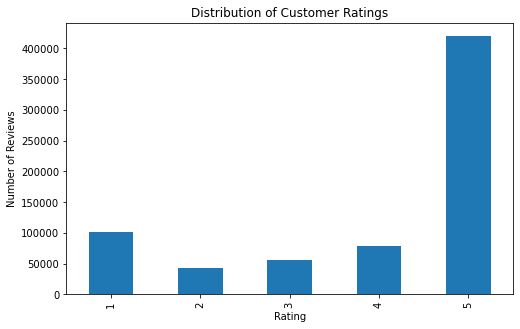

In [58]:
plt.figure(figsize=(8,5))

reviews["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

### Interpretation

The rating distribution provides an overview of customer sentiment across the dataset.

A strong concentration of 4-star and 5-star ratings would indicate generally positive customer experiences, while large proportions of 1-star and 2-star ratings would suggest widespread dissatisfaction.

The distribution also provides context for later sentiment-classification models, since the balance of positive and negative examples influences model performance.

### 3.2 Distribution of Review Length

Review length serves as a proxy for customer engagement.

While ratings summarize satisfaction numerically, review length provides insight into how much effort customers invested in describing their experiences.

The following histogram illustrates the distribution of review lengths.

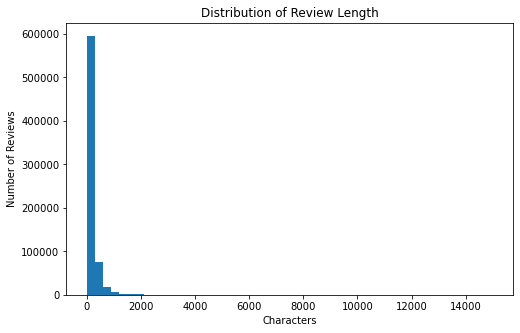

In [59]:
plt.figure(figsize=(8,5))

plt.hist(
    reviews["review_length"],
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Characters")
plt.ylabel("Number of Reviews")

plt.show()

### Interpretation

Review length is often highly skewed, with many short reviews and a smaller number of detailed reviews.

Longer reviews may contain richer information and are particularly valuable for natural language processing and sentiment analysis.

### 3.3 Helpful Vote Analysis

Helpful votes represent feedback from other customers regarding the usefulness of a review.

Reviews receiving high numbers of helpful votes may indicate detailed explanations, strong customer experiences, or issues that resonate with a broader audience.

The following summary statistics provide an overview of helpful-vote behavior.

In [43]:
reviews["helpful_vote"].describe()

count   701,528.000
mean          0.924
std           5.471
min           0.000
25%           0.000
50%           0.000
75%           1.000
max         646.000
Name: helpful_vote, dtype: float64

### Interpretation

Helpful-vote statistics help identify the extent to which reviews influence other customers.

A small number of reviews often accumulate a disproportionately large number of helpful votes, indicating that customer influence is not evenly distributed across reviews.

### 3.4 Verified Purchase Distribution

Verified purchases provide additional confidence that a review originates from an actual customer transaction.

The proportion of verified purchases helps assess the credibility of the review dataset.

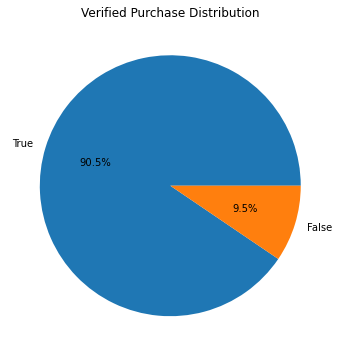

In [60]:
verified_counts = (
    reviews["verified_purchase"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    verified_counts,
    labels=verified_counts.index,
    autopct="%1.1f%%"
)

plt.title("Verified Purchase Distribution")

plt.show()

### Interpretation

A high percentage of verified purchases strengthens confidence in the reliability of customer feedback.

This observation is important because later KPI calculations and machine-learning models depend on review quality and authenticity.

## Key Observations from Exploratory Analysis

Several important observations emerged from the exploratory analysis:

- Customer ratings provide an initial measure of satisfaction.
- Review length varies substantially across customers, indicating different engagement levels.
- Helpful votes are unevenly distributed, suggesting that some reviews have significantly greater influence than others.
- Verified purchases account for the majority of reviews, increasing confidence in dataset reliability.

These findings provide the foundation for constructing product-level KPIs and performing more advanced analytics in subsequent sections.

# 4. Product-Level KPI Framework

Managers typically make decisions about products rather than individual reviews.

Although review-level analysis provides valuable information about customer behavior, product-management decisions require aggregated indicators that summarize product performance.

To support product intelligence, review-level observations are transformed into product-level Key Performance Indicators (KPIs).

The following KPIs are developed:

- Average Rating
- Review Count
- Negative Review Rate
- Verified Purchase Rate
- Average Helpful Votes
- Average Review Length

Together, these indicators provide a multidimensional view of product performance, customer satisfaction, engagement, and trust.

### 4.1 Product-Level Aggregation

Each product may receive multiple customer reviews.

To evaluate products rather than individual reviews, review-level observations are aggregated using the product identifier (`parent_asin`).

This process transforms hundreds of thousands of reviews into a product-level analytical dataset suitable for KPI analysis, clustering, and risk assessment.

In [61]:
product_kpis = (
    reviews.groupby("parent_asin")
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("rating", "count"),
        negative_review_rate=("negative_review", "mean"),
        verified_purchase_rate=("verified_purchase", "mean"),
        avg_helpful_votes=("helpful_vote", "mean"),
        avg_review_length=("review_length", "mean")
    )
    .reset_index()
)

product_kpis.head()

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length
0,0005946468,5.000,1,0.000,1.000,0.000,5.000
1,0123034892,5.000,1,0.000,1.000,0.000,12.000
2,0124784577,4.333,3,0.000,1.000,0.333,61.667
3,0515059560,4.000,1,0.000,1.000,1.000,196.000
4,0692508988,5.000,1,0.000,1.000,0.000,273.000


# Interpretation

The aggregation process converts review-level observations into product-level performance indicators.

Each row now represents one product rather than one review.

This transformation is important because subsequent analyses focus on evaluating products, identifying risk patterns, and discovering product segments rather than analyzing individual customer reviews.

### 4.2 Product KPI Overview

Before developing risk metrics and segmentation models, it is useful to examine the overall characteristics of the product-level dataset.

Summary statistics provide insight into the distribution of ratings, review volume, engagement, and customer trust across products.

In [63]:
product_kpis.describe()

,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length
count,"112,565.000","112,565.000","112,565.000","112,565.000","112,565.000","112,565.000"
mean,3.815,6.232,0.244,0.908,0.592,165.712
std,1.298,25.190,0.353,0.246,1.999,194.479
min,1.000,1.000,0.000,0.000,0.000,0.000
25%,3.000,1.000,0.000,1.000,0.000,66.000
50%,4.167,2.000,0.000,1.000,0.000,120.000
75%,5.000,4.000,0.400,1.000,0.667,200.000
max,5.000,"1,962.000",1.000,1.000,314.000,"14,989.000"


### Interpretation

The KPI summary reveals substantial variation among products.

Some products receive large numbers of reviews while others receive very few. This variation is important because products supported by only a small number of reviews may produce unstable or misleading KPI values.

Consequently, review volume must be considered when evaluating product performance.

### 4.3 Statistical Reliability and Review Volume

A product with a single five-star review is not necessarily superior to a product with hundreds of reviews and an average rating of 4.7.

Review volume affects the reliability of product-level metrics.

To improve analytical reliability, products with very small numbers of reviews are filtered before segmentation and risk analysis.

In [ ]:
product_kpis["review_count"].describe()

### Interpretation

Review-count statistics indicate how much customer feedback supports each product.

Products with very few reviews may produce unstable average ratings and should therefore be interpreted cautiously.

This observation motivates the creation of a reliability threshold for advanced analyses.

### 4.4 Reliable Product Selection

To improve statistical stability, products with fewer than 20 reviews are excluded from segmentation and risk modeling.

This threshold does not imply that products with fewer reviews are unimportant. Rather, it reflects a desire to focus advanced analysis on products supported by sufficient customer feedback.

In [64]:
reliable_products = product_kpis[
    product_kpis["review_count"] >= MIN_PRODUCT_REVIEWS
].copy()

print(
    f"Reliable products: {len(reliable_products):,}"
)

Reliable products: 6,044


### Interpretation

The filtered dataset contains products supported by at least twenty customer reviews.

This subset serves as the foundation for subsequent risk scoring, product segmentation, and machine-learning analyses.

By reducing the influence of products with extremely limited feedback, the resulting insights become more statistically reliable.

## Key Findings

The review-level dataset was successfully transformed into a product-level KPI framework.

The analysis demonstrates that product evaluation requires more than average ratings alone. Review volume, customer dissatisfaction, engagement, and trust indicators all contribute to a more comprehensive understanding of product performance.

To improve analytical reliability, products supported by fewer than twenty reviews were excluded from advanced modeling.

# 5. Product Risk Analytics

Product managers often need to prioritize products that require attention.

In large e-commerce environments, manually examining thousands of products is impractical. Consequently, organizations frequently rely on composite indicators that combine multiple KPIs into a single decision-support metric.

This section develops a Product Risk Score that integrates customer satisfaction, customer dissatisfaction, and review trust indicators.

The objective is not to produce a perfect measure of product quality, but rather to create a practical framework for identifying products that may warrant further investigation.

### 5.1 Why a Risk Score is Needed

Individual KPIs provide useful information but may be difficult to interpret collectively.

For example:

- A product may have a low average rating.
- Another product may have a high negative-review rate.
- A third product may have a low verified-purchase rate.

Managers must often evaluate multiple indicators simultaneously.

A composite risk score simplifies this process by combining several KPIs into a single prioritization metric.

### 5.2 Risk Score Development

The initial risk framework combines three dimensions:

1. Customer Satisfaction (Average Rating)
2. Customer Dissatisfaction (Negative Review Rate)
3. Review Trust (Verified Purchase Rate)

Products with lower ratings, higher negative-review rates, and lower verified-purchase rates receive higher risk scores.

The weighting scheme is exploratory and is intended to demonstrate a practical decision-support approach rather than an optimized production model.

In [66]:
reliable_products["risk_score"] = (
    (1 - reliable_products["avg_rating"] / 5) * 40
    + reliable_products["negative_review_rate"] * 40
    + (1 - reliable_products["verified_purchase_rate"]) * 20
)

### 5.3 Risk Score Distribution

Before using the risk score for prioritization, it is important to understand its distribution.

A histogram allows us to examine whether most products exhibit low risk, high risk, or a mixture of both.

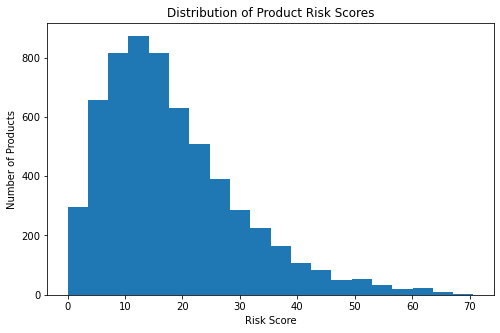

In [67]:
plt.figure(figsize=(8,5))

plt.hist(
    reliable_products["risk_score"],
    bins=20
)

plt.title("Distribution of Product Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Products")

plt.show()

### Interpretation

The distribution indicates how product risk is spread across the portfolio.

Most products appear within lower risk ranges, while a smaller number of products occupy the upper tail of the distribution.

This pattern is consistent with many marketplace environments, where a relatively small number of products generate a disproportionate share of customer dissatisfaction.

### 5.4 Highest-Risk Products

Products with the highest risk scores represent the most concerning combinations of dissatisfaction, low ratings, and trust-related indicators.

These products may warrant further investigation by product managers or marketplace administrators.

In [68]:
high_risk_products = (
    reliable_products
    .sort_values(
        "risk_score",
        ascending=False
    )
)

high_risk_products.head(10)

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length,risk_score
1661,B00170DB4E,2.000,24,0.708,0.083,3.500,497.708,70.667
37386,B0713ZQ6B5,1.200,20,0.950,0.950,1.600,47.200,69.400
107540,B09LD7SQXH,1.185,54,0.963,1.000,0.926,137.907,69.037
58990,B07MP69QK1,1.381,63,0.921,0.921,0.111,189.921,67.365
65524,B07SVBRXHL,1.294,34,0.912,1.000,0.353,122.588,66.118
41394,B074XCKC7X,1.519,27,0.889,0.889,0.148,233.704,65.630
47437,B07BDDBRMJ,1.468,47,0.915,0.979,0.851,154.234,65.277
95070,B08R6BSWSH,1.480,25,0.920,1.000,0.440,109.480,64.960
1639,B00168F4VK,1.536,28,0.893,0.929,5.821,217.000,64.857
61620,B07PSCB3FT,1.429,21,0.905,1.000,0.333,102.381,64.762


### Interpretation

The highest-risk products exhibit a combination of unfavorable KPI characteristics.

Although the risk score should not be interpreted as a definitive measure of product quality, it provides a practical method for prioritizing managerial attention and identifying products that may require corrective action.

### 5.5 Limitations of the Initial Risk Model

The initial risk framework is intentionally simple and therefore has several limitations.

First, the weighting scheme is based on analytical judgment rather than formal optimization.

Second, some KPIs may be highly correlated and therefore partially redundant.

For example, average rating and negative-review rate may capture similar aspects of customer dissatisfaction.

The following section investigates these relationships through correlation analysis and evaluates whether the current risk model can be improved.

# 6. Correlation Analysis and KPI Validation

Developing KPIs is only the first step in analytics.

It is equally important to evaluate whether the selected indicators provide unique information or whether some metrics are effectively measuring the same underlying phenomenon.

Correlation analysis helps identify relationships between KPIs and can reveal redundancy within a measurement framework.

Understanding these relationships improves both interpretability and model design.

### 6.1 Correlation Analysis

The following analysis examines relationships among the primary product-level KPIs.

Pearson correlation coefficients range from:

- +1 : perfect positive relationship
- 0 : no linear relationship
- -1 : perfect negative relationship

Strong correlations may indicate that two KPIs are capturing similar information.

In [69]:
corr_matrix = reliable_products[
    [
        "avg_rating",
        "negative_review_rate",
        "verified_purchase_rate",
        "review_count"
    ]
].corr()

corr_matrix

,avg_rating,negative_review_rate,verified_purchase_rate,review_count
avg_rating,1.000,-0.976,-0.063,0.046
negative_review_rate,-0.976,1.000,0.103,-0.042
verified_purchase_rate,-0.063,0.103,1.000,0.031
review_count,0.046,-0.042,0.031,1.000


### Interpretation

The correlation matrix provides a quantitative assessment of how product KPIs move together.

Particular attention is given to the relationship between average rating and negative-review rate, as both variables are intended to capture aspects of customer satisfaction and dissatisfaction.

### 6.2 Correlation Heatmap

While numerical correlation tables are informative, visual representations often make patterns easier to identify.

The heatmap below highlights both strong positive and strong negative relationships among KPIs.

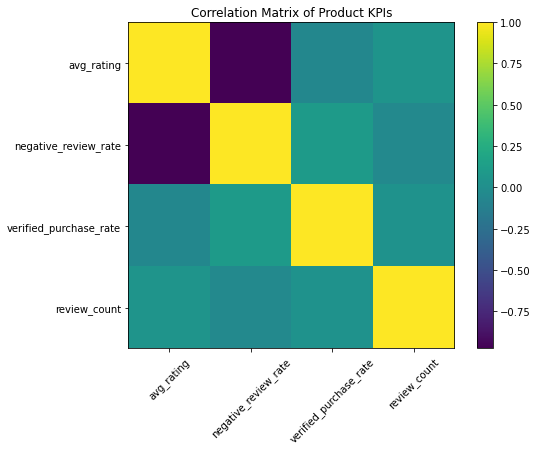

In [70]:
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title(
    "Correlation Matrix of Product KPIs"
)

plt.show()

### 6.3 Key Finding: KPI Redundancy

One of the most important findings of this project is the extremely strong inverse relationship between average rating and negative-review rate.

The correlation coefficient is approximately:

r = -0.976

This indicates that products with higher average ratings almost always exhibit lower negative-review rates.

Conversely, products with lower average ratings tend to exhibit substantially higher negative-review rates.

The strength of this relationship suggests that the two KPIs are partially redundant and may capture similar aspects of customer satisfaction.

### 6.4 Implications for Product Risk Analytics

The correlation analysis reveals an important limitation of the initial risk framework.

The original risk score assigned substantial weight to both average rating and negative-review rate.

However, because these KPIs are highly correlated, the framework may effectively count customer dissatisfaction twice.

This observation does not invalidate the risk score. Rather, it highlights an opportunity for future refinement through statistical weighting, optimization techniques, or feature-selection methods.

The analysis demonstrates the importance of validating KPI frameworks rather than relying solely on intuitive assumptions.

### 6.5 Additional Observations

Two additional findings emerged from the correlation analysis:

1. Verified Purchase Rate exhibited only weak relationships with other KPIs.

2. Review Count exhibited little relationship with Average Rating.

These observations suggest that product popularity and review verification do not strongly determine customer satisfaction within this dataset.

Such findings are useful because they challenge common assumptions and encourage evidence-based decision-making.

## Key Findings

Correlation analysis revealed that KPI validation is a critical step in product analytics.

The strongest relationship was observed between Average Rating and Negative Review Rate (r = -0.976), indicating substantial overlap between these measures.

The results suggest that future KPI frameworks should carefully consider redundancy when constructing composite metrics.

These findings provide a stronger foundation for the machine-learning analyses that follow.

# 7. Product Segmentation Using K-Means Clustering

Not all products behave similarly.

Some products consistently receive high ratings and positive customer feedback, while others exhibit elevated dissatisfaction levels or unusual review patterns.

Rather than manually categorizing products, machine-learning techniques can identify naturally occurring groups within the data.

This section applies K-Means clustering, an unsupervised machine-learning algorithm, to discover product segments based on KPI characteristics.

Unlike supervised learning, K-Means does not require predefined labels. Instead, it identifies groups of products that exhibit similar behavior across multiple KPIs.

### 7.1 Feature Selection

Clustering performance depends heavily on the variables used to represent each observation.

The following product-level KPIs were selected:

- Average Rating
- Review Count
- Verified Purchase Rate
- Average Helpful Votes
- Average Review Length

Together, these variables capture customer satisfaction, engagement, review credibility, and product popularity.

Because some variables operate on different scales, normalization is required before clustering.

In [71]:
cluster_data = reliable_products[
    [
        "avg_rating",
        "review_count",
        "verified_purchase_rate",
        "avg_helpful_votes",
        "avg_review_length"
    ]
].copy()

cluster_data.head()

,avg_rating,review_count,verified_purchase_rate,avg_helpful_votes,avg_review_length
5,4.780,41,0.976,2.073,206.610
16,4.900,30,0.300,0.200,497.400
68,4.296,27,0.963,1.259,84.741
72,4.185,27,0.185,3.926,912.667
76,4.495,196,0.786,1.980,454.117


### 7.2 Log Transformation

Review counts, helpful votes, and review lengths often exhibit highly skewed distributions.

A small number of products may receive exceptionally large values, while most products remain concentrated at lower levels.

To reduce the influence of extreme observations, a logarithmic transformation is applied before standardization.

This transformation improves clustering stability and prevents a small number of highly popular products from dominating the analysis.

In [72]:
cluster_data["review_count"] = np.log1p(
    cluster_data["review_count"]
)

cluster_data["avg_helpful_votes"] = np.log1p(
    cluster_data["avg_helpful_votes"]
)

cluster_data["avg_review_length"] = np.log1p(
    cluster_data["avg_review_length"]
)

### 7.3 Feature Standardization

The selected KPIs operate on different numerical scales.

For example:

- Average Rating ranges approximately from 1 to 5.
- Review Count may exceed hundreds of reviews.
- Verified Purchase Rate ranges between 0 and 1.

Without standardization, variables with larger numerical values would disproportionately influence clustering results.

StandardScaler transforms each variable so that:

- Mean ≈ 0
- Standard Deviation ≈ 1

This ensures that all KPIs contribute more equally to the clustering process.

In [74]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_data
)

cluster_scaled[:5]

array([[ 1.2349149 , -0.05724087,  0.45431306,  1.25135554,  0.60545915],
       [ 1.41927712, -0.49838894, -3.71031418, -0.96009873,  2.61258333],
       [ 0.48799008, -0.64624485,  0.37635507,  0.52781992, -1.42135076],
       [ 0.31658756, -0.64624485, -4.41806137,  2.36086476,  4.00162512],
       [ 0.79435752,  2.18789865, -0.71625004,  1.17863457,  2.40436858]])

### 7.4 Cluster Selection

One of the most important decisions in K-Means clustering is determining the number of clusters.

Several approaches exist, including the Elbow Method and Silhouette Analysis.

In this project, four clusters were selected because they produced interpretable business segments and meaningful separation among products.

The objective of clustering is not merely mathematical optimization, but the discovery of useful managerial insights.

### 7.5 K-Means Model

K-Means partitions observations into groups such that products within the same cluster are more similar to one another than to products in other clusters.

The algorithm iteratively assigns products to cluster centers and updates those centers until convergence.

In [75]:
kmeans = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=10
)

reliable_products["cluster"] = (
    kmeans.fit_predict(cluster_scaled)
)

reliable_products["cluster"].value_counts()

3    2789
1    1357
0    1270
2     628
Name: cluster, dtype: int64

### 7.6 Cluster Profiling

K-Means produces numerical cluster labels.

However, numerical labels alone do not provide business meaning.

To interpret the clusters, average KPI values are calculated for each group.

In [76]:
cluster_profiles = (
    reliable_products
    .groupby("cluster")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("avg_rating", "mean"),
        avg_review_count=("review_count", "mean"),
        avg_negative_rate=("negative_review_rate", "mean"),
        avg_verified_rate=("verified_purchase_rate", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .round(3)
)

cluster_profiles

,products,avg_rating,avg_review_count,avg_negative_rate,avg_verified_rate,avg_risk_score
cluster,,,,,,
0,1270,4.139,153.497,0.162,0.933,14.706
1,1357,3.119,36.252,0.416,0.949,32.724
2,628,4.115,41.946,0.150,0.511,22.867
3,2789,4.296,34.143,0.126,0.953,11.621


### 7.7 Business Interpretation of Product Segments

The clustering analysis identified four distinct product segments.

#### Cluster 0 – Popular Products

Products in this cluster receive substantially higher review volumes and represent highly visible products within the marketplace.

#### Cluster 1 – High-Risk Products

This segment exhibits the lowest average ratings, the highest negative-review rates, and the highest risk scores.

These products may require managerial attention.

#### Cluster 2 – Trust Anomaly Products

These products exhibit unusually low verified-purchase rates relative to other segments.

Further investigation may be warranted.

#### Cluster 3 – Customer Favorites

Products in this cluster exhibit the highest ratings and the lowest risk scores.

These products represent the strongest-performing segment within the portfolio.

## Key Findings

K-Means clustering successfully identified four distinct product segments.

The results demonstrate that products differ not only in customer satisfaction but also in review volume, engagement patterns, and trust indicators.

These findings provide a foundation for visualizing cluster relationships using Principal Component Analysis (PCA) in the next section.

# 8. Principal Component Analysis (PCA)

The clustering model developed in the previous section operates in a multidimensional feature space.

Each product is represented using multiple KPIs, including ratings, review volume, verified-purchase rate, helpful votes, and review length.

Because humans cannot directly visualize high-dimensional data, Principal Component Analysis (PCA) is applied to reduce the dimensionality of the dataset while preserving as much information as possible.

The objective of PCA is visualization and interpretation.

Importantly, PCA does not create the clusters. The clusters were produced by the K-Means algorithm. PCA is used only to project the high-dimensional clustering results into a two-dimensional space that can be visualized and interpreted.

### 8.1 Why PCA is Needed

The clustering model operates on five KPI variables:

- Average Rating
- Review Count
- Verified Purchase Rate
- Average Helpful Votes
- Average Review Length

Together, these variables define a five-dimensional feature space.

While machine-learning algorithms can operate in high-dimensional spaces, visual interpretation becomes difficult.

PCA addresses this challenge by creating new variables, called Principal Components, that capture the dominant patterns of variation within the data.

The first principal component (PC1) captures the largest amount of variation.

The second principal component (PC2) captures the next largest amount of variation while remaining independent of PC1.

### 8.2 PCA Transformation

The standardized KPI dataset is transformed into two principal components.

These components are used solely for visualization purposes.

In [77]:
pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(
    cluster_scaled
)

cluster_pca[:5]

array([[ 0.51629328,  0.60602905],
       [ 3.95544003, -2.70301153],
       [-1.13030185, -0.03964411],
       [ 6.31839699, -0.34222068],
       [ 2.62859208,  1.49252924]])

### 8.3 Explained Variance

An important measure in PCA is the explained variance ratio.

This metric indicates how much of the original information is preserved by each principal component.

Higher values indicate that the component captures a larger proportion of the variation present in the original dataset.

The cumulative explained variance indicates how much information is retained after dimensionality reduction.

In [78]:
explained_variance = (
    pca.explained_variance_ratio_
)

print(
    "Explained Variance Ratio:",
    explained_variance
)

print(
    "Total Variance Preserved:",
    explained_variance.sum()
)

Explained Variance Ratio: [0.30985338 0.23295204]
Total Variance Preserved: 0.5428054203206367


### Interpretation

The first principal component captures approximately 31% of the total variance, while the second captures approximately 23%.

Together, the first two principal components preserve approximately 54% of the information contained in the original KPI space.

Although some information is lost during dimensionality reduction, the retained variance is sufficient to visualize broad clustering patterns and segment relationships.

### 8.4 Cluster Visualization

The PCA projection enables visual examination of the clusters identified by K-Means.

Each point in the figure represents a product.

Products located close together exhibit similar KPI characteristics, while products located far apart differ substantially.

Color indicates cluster membership assigned by the K-Means algorithm.

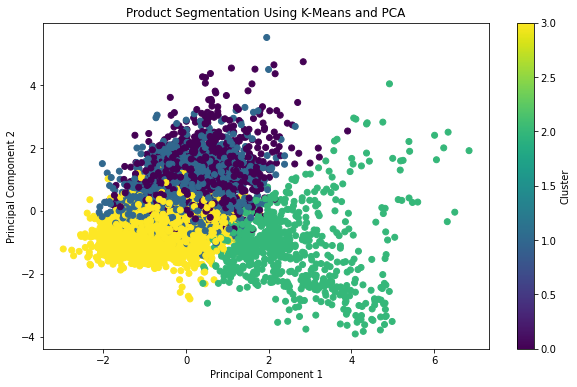

In [79]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_pca[:,0],
    cluster_pca[:,1],
    c=reliable_products["cluster"]
)

plt.title(
    "Product Segmentation Using K-Means and PCA"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

### 8.5 Interpretation

Several observations emerge from the PCA visualization.

First, the clustering structure remains visible after dimensionality reduction, suggesting that the identified product segments represent meaningful differences in KPI behavior.

Second, some clusters exhibit greater dispersion than others, indicating greater internal variation among products.

Finally, the visualization provides an intuitive representation of how products are distributed across the product-performance landscape.

It is important to emphasize that PCA did not generate the clusters. The clusters were generated by K-Means and subsequently visualized using PCA.

## Key Findings

Principal Component Analysis successfully reduced the dimensionality of the KPI dataset from five variables to two principal components.

The first two components preserved approximately 54% of the total variance and enabled effective visualization of product segments.

The PCA visualization confirmed the presence of distinct product groups and improved interpretability of the clustering results.

In [80]:
cluster_names = {
    0: "Popular Products",
    1: "High-Risk Products",
    2: "Trust Anomaly Products",
    3: "Customer Favorites"
}

reliable_products["cluster_name"] = (
    reliable_products["cluster"]
    .map(cluster_names)
)

# 9. NLP-Based Sentiment Classification

Customer ratings provide structured feedback, but review text contains significantly richer information.

Natural Language Processing (NLP) enables extraction of insights directly from customer comments.

This section develops a text-classification model that predicts review sentiment from review text alone.

The objective is to determine whether customer-written reviews contain sufficient information to accurately identify positive and negative experiences.

### 9.1 Sentiment Label Creation

To build a supervised machine-learning model, sentiment labels must first be created.

Reviews with ratings of:

- 4–5 stars are classified as Positive
- 1–2 stars are classified as Negative

Three-star reviews are excluded because they often represent neutral or ambiguous opinions.

This approach produces a clearer distinction between positive and negative customer experiences.

In [81]:
ml_data = reviews.copy()

ml_data = ml_data[
    ml_data["rating"] != 3
].copy()

ml_data["target"] = (
    ml_data["rating"] >= 4
).astype(int)

ml_data["review_text"] = (
    ml_data["title"].astype(str)
    + " "
    + ml_data["text"].astype(str)
)

ml_data = ml_data[
    ml_data["review_text"].str.len() > 10
].copy()

ml_data[["rating","target","review_text"]].head()

,rating,target,review_text
0,5,1,Such a lovely scent but not overpowering. This...
1,4,1,Works great but smells a little weird. This pr...
2,5,1,"Yes! Smells good, feels great!"
3,1,0,Synthetic feeling Felt synthetic
5,4,1,Pretty Color The polish was quiet thick and di...


### Interpretation

The sentiment-classification dataset consists of customer reviews labeled according to rating behavior.

The target variable is binary:

- 1 = Positive Review
- 0 = Negative Review

This formulation converts a business problem into a supervised machine-learning task.

### 9.2 Sampling Strategy

The full dataset contains hundreds of thousands of reviews.

To reduce computational requirements while maintaining representativeness, a random sample of 100,000 reviews is selected.

Random sampling preserves the overall distribution of review characteristics while improving processing efficiency.

In [82]:
ml_sample = ml_data.sample(
    n=100000,
    random_state=42
)

ml_sample["target"].value_counts(
    normalize=True
)

1   0.774
0   0.226
Name: target, dtype: float64

# 10. Managerial Insights and Recommendations

The objective of analytics is not only to identify patterns but also to support decision-making.

Based on the KPI framework, risk analysis, clustering results, and sentiment-classification model, several practical insights emerge.

These findings may assist product managers, marketplace operators, and customer-experience teams in prioritizing actions and improving product performance.

### 10.1 Product Segmentation Insights

The clustering analysis identified four distinct product segments:

- Customer Favorites
- Popular Products
- High-Risk Products
- Trust Anomaly Products

Each segment exhibits unique behavioral characteristics and may require different management strategies.

Rather than applying uniform policies across all products, organizations can allocate resources more efficiently by targeting interventions toward specific segments.

### 10.2 Managing High-Risk Products

Products classified within the High-Risk segment exhibited:

- Lower average ratings
- Higher negative-review rates
- Elevated risk scores

These products should be prioritized for investigation.

Potential actions include:

- Product-quality reviews
- Supplier evaluation
- Customer-complaint analysis
- Product-description improvements
- Inventory-quality audits

Because these products generate disproportionate customer dissatisfaction, corrective actions may produce substantial improvements in customer experience.

### 10.3 Leveraging Customer Favorites

Products classified as Customer Favorites achieved the highest average ratings and lowest risk scores.

These products represent organizational strengths and may provide opportunities for:

- Increased promotion
- Bundling strategies
- Advertising campaigns
- Product-line expansion

Studying the characteristics of these products may also reveal best practices that can be applied to weaker-performing products.

### 10.4 Monitoring Trust Anomaly Products

One cluster exhibited unusually low verified-purchase rates despite maintaining relatively strong rating performance.

These products were labeled Trust Anomaly Products.

Although low verified-purchase rates do not necessarily indicate fraudulent behavior, they may warrant additional monitoring because customer trust indicators differ substantially from the broader marketplace.

Further investigation could include:

- Review authenticity analysis
- Marketplace monitoring
- Verification-policy evaluation

### 10.5 Customer Review Intelligence

The sentiment-classification model achieved approximately 93.5% accuracy when predicting customer sentiment from review text.

This finding suggests that review text contains substantial information regarding customer satisfaction.

Organizations can use NLP models to:

- Automatically monitor customer sentiment
- Identify emerging product issues
- Detect dissatisfaction earlier
- Support customer-service operations

Such systems can significantly reduce the need for manual review analysis.

### 10.6 Language Patterns in Customer Reviews

The NLP analysis identified words strongly associated with positive and negative reviews.

Positive reviews frequently included terms such as:

- excellent
- fantastic
- favorite
- perfect
- amazing
- beautiful

Negative reviews frequently included terms such as:

- terrible
- disappointing
- broken
- awful
- waste
- doesn't work

These findings demonstrate that customer language patterns can provide actionable indicators of satisfaction and dissatisfaction.

## Key Findings

The analysis demonstrates that customer-review data can support both operational and strategic decision-making.

Product segmentation identified meaningful differences among products, while sentiment analysis revealed that customer-written reviews contain strong predictive signals regarding satisfaction.

Together, these methods provide a scalable framework for product intelligence and customer-experience management.

# 11. Conclusion

This project developed a Product Intelligence and Customer Review Analytics framework using Amazon Beauty review data.

The analysis combined statistical methods, product-performance KPIs, machine-learning techniques, and natural language processing to investigate customer behavior and product performance at scale.

The study began with review-level analysis and feature engineering before constructing a product-level KPI framework consisting of:

- Average Rating
- Review Count
- Negative Review Rate
- Verified Purchase Rate
- Average Helpful Votes
- Average Review Length

These indicators were used to evaluate product performance and support the development of a composite Product Risk Score.

Correlation analysis revealed a strong inverse relationship between Average Rating and Negative Review Rate (r ≈ -0.976), highlighting the importance of KPI validation and demonstrating that certain indicators may capture similar aspects of customer satisfaction.

K-Means clustering identified four distinct product segments:

- Popular Products
- High-Risk Products
- Trust Anomaly Products
- Customer Favorites

These segments provided meaningful business insights and demonstrated that products differ substantially in terms of customer satisfaction, engagement, trust, and risk.

Principal Component Analysis (PCA) successfully reduced the dimensionality of the KPI space and enabled visualization of the discovered product segments.

Finally, Natural Language Processing techniques were applied to customer review text. Using TF-IDF feature extraction and Logistic Regression classification, the sentiment model achieved approximately 93.5% prediction accuracy, demonstrating that customer-written reviews contain strong predictive signals regarding customer satisfaction.

Overall, the results suggest that customer review data can serve as a valuable source of product intelligence and decision support. The framework developed in this study illustrates how data analytics, machine learning, and natural language processing can be integrated to support evidence-based product management.

# 12. Future Work

Several opportunities exist for extending this analysis.

First, alternative clustering approaches such as Hierarchical Clustering, DBSCAN, or Gaussian Mixture Models could be evaluated and compared with K-Means.

Second, the Product Risk Score could be improved using data-driven weighting approaches rather than manually assigned weights.

Third, more advanced natural language processing models such as Word Embeddings, Transformer-based architectures, or Large Language Models (LLMs) could be investigated to improve sentiment-classification performance.

Fourth, time-series analysis could be incorporated to examine how customer sentiment and product performance evolve over time.

Finally, integrating additional product information such as price, category characteristics, and sales performance could provide a more comprehensive product-intelligence framework.

These extensions may further improve the practical value and predictive capability of the proposed analytical framework.